# Experimentos — Análise de Sistemas de Segunda Ordem

Disciplina: Introdução aos Sistemas de Controle

Aluno 1: Inácio Rodrigues de Matos Galvão — Matrícula: 485178

Aluno 2: Leonardo Monteiro de Sousa — Matrícula: 540707

---

## 1. Introdução

Neste trabalho, simulamos o comportamento de sistemas de controle de segunda ordem quando mexemos em diferentes parâmetros: amortecimento, polos, zeros e ganho de malha. A ideia é ver na prática o que a teoria prevê.

São quatro experimentos:

- **Experimento 1**: variar o fator de amortecimento $\zeta$ e ver como a resposta ao degrau muda entre os regimes subamortecido, criticamente amortecido e superamortecido.
- **Experimento 2**: adicionar polos extras à FTMF e ver o que acontece com o tempo de acomodação.
- **Experimento 3**: colocar zeros na FT e observar como eles aceleram ou desaceleram a resposta.
- **Experimento 4**: variar o ganho $K$ e acompanhar a mudança na posição dos polos e na estabilidade.

Os códigos originais foram feitos em Scilab. Aqui convertemos tudo para Python com a biblioteca `control`.

In [1]:
# Instala as dependências (execute apenas uma vez)
%pip install -q control numpy matplotlib scipy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /home/inacio/.pyenv/versions/3.14.2/bin/python3.14 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl
import os

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['grid.alpha'] = 0.3

# Garante que a pasta de figuras existe
os.makedirs('figuras', exist_ok=True)

# Função para imprimir a FT de forma limpa
def print_tf(name, sys):
    s = str(sys)
    lines = s.strip().split('\n')
    frac_lines = [l for l in lines if not l.startswith('<') and not l.startswith('Inputs') and not l.startswith('Outputs')]
    print(f"{name}")
    print('\n'.join(frac_lines))
    print()

print("Dependências carregadas com sucesso.")

Dependências carregadas com sucesso.


---

## Experimento 1 — Resposta ao degrau para diferentes fatores de amortecimento

### Objetivo

Simular a resposta ao degrau unitário de um sistema de segunda ordem com $\omega_n = 100.000$ rad/s para três valores de $\zeta$: 0,5 (subamortecido), 1 (criticamente amortecido) e 1,5 (superamortecido).

### Função de transferência

$$P(s) = \frac{\omega_n^2}{s^2 + 2\zeta\omega_n s + \omega_n^2}$$

### Parâmetros

| Parâmetro | Valor | O que é |
|-----------|-------|---------|
| $\omega_n$ | 100.000 rad/s | Frequência natural |
| $\zeta$ | 0,5 / 1 / 1,5 | Fator de amortecimento |

--- ζ = 0.5 ---
P(s):

          1e+10
  ---------------------
  s^2 + 1e+05 s + 1e+10

Polos: [-50000.+86602.54037844j -50000.-86602.54037844j]
Ganho DC: 1.0000

--- ζ = 1.0 ---
P(s):

          1e+10
  ---------------------
  s^2 + 2e+05 s + 1e+10

Polos: [-100000.+0.j -100000.+0.j]
Ganho DC: 1.0000

--- ζ = 1.5 ---
P(s):

          1e+10
  ---------------------
  s^2 + 3e+05 s + 1e+10

Polos: [-261803.39887499+0.j  -38196.60112501+0.j]
Ganho DC: 1.0000



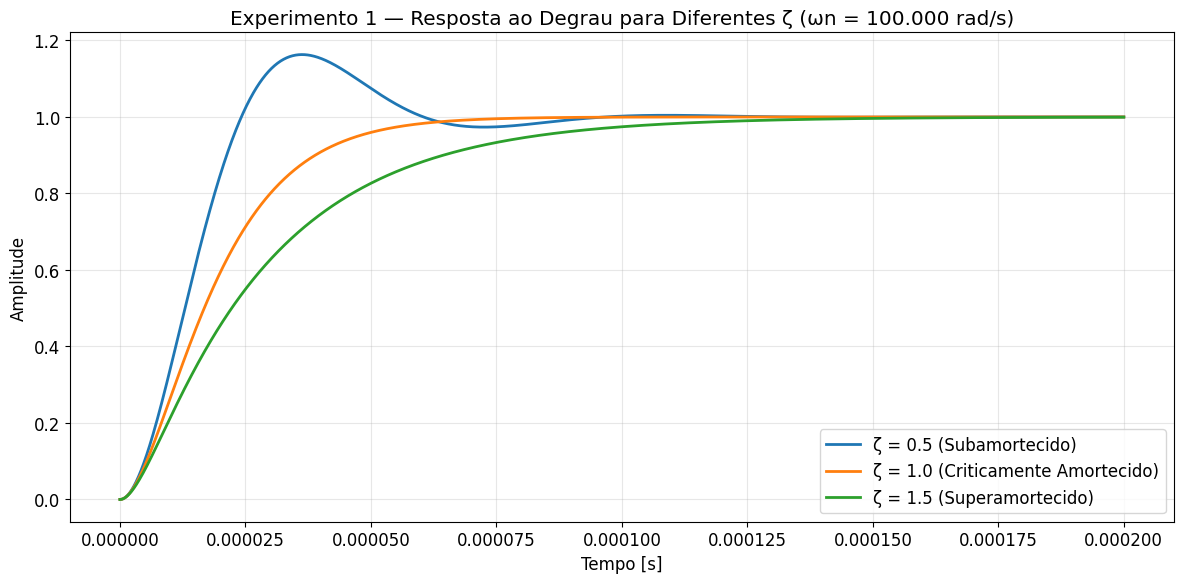

In [3]:
# ==================== Experimento 1: Resposta ao Degrau ====================

wn = 100000  # Frequência natural [rad/s]
zetas = [0.5, 1.0, 1.5]
labels = ['ζ = 0.5 (Subamortecido)', 'ζ = 1.0 (Criticamente Amortecido)', 'ζ = 1.5 (Superamortecido)']
colors = ['tab:blue', 'tab:orange', 'tab:green']

# Vetor de tempo (muito pequeno devido ao wn alto)
t = np.arange(0, 0.0002, 0.0000001)

fig, ax = plt.subplots(figsize=(12, 6))

for i, zeta in enumerate(zetas):
    # P(s) = wn^2 / (s^2 + 2*zeta*wn*s + wn^2)
    P = ctrl.tf([wn**2], [1, 2*zeta*wn, wn**2])
    t_out, y_out = ctrl.step_response(P, T=t)
    ax.plot(t_out, y_out, color=colors[i], label=labels[i])

    print(f"--- ζ = {zeta} ---")
    print_tf("P(s):", P)
    print(f"Polos: {P.poles()}")
    print(f"Ganho DC: {ctrl.dcgain(P):.4f}")
    print()

ax.set_xlabel('Tempo [s]')
ax.set_ylabel('Amplitude')
ax.set_title('Experimento 1 — Resposta ao Degrau para Diferentes ζ (ωn = 100.000 rad/s)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('figuras/exp1_resposta_degrau.png', dpi=150, bbox_inches='tight')
plt.show()

### Respostas — Experimento 1

**Questão 1: Classificação e resposta**

a) $\zeta = 0{,}5$ -- Subamortecido. A resposta oscila em torno do valor final antes de estabilizar. Dá para ver o overshoot e as oscilações com amplitude cada vez menor no gráfico.

b) $\zeta = 1$ -- Criticamente amortecido. A curva sobe suave até 1, sem oscilação. É o jeito mais rápido de chegar no valor final sem ultrapassar.

c) $\zeta = 1{,}5$ -- Superamortecido. Sem oscilação também, mas mais devagar que o caso crítico. A curva demora para chegar lá.

**Questão 2: Desempenho transitório**

(a) O Rise Time mais rápido é o de $\zeta = 0{,}5$. O sistema subamortecido sobe rápido justamente porque "passa do ponto" -- a componente oscilatória acelera a subida.

(b) O Settling Time mais longo é o de $\zeta = 1{,}5$. Como o superamortecido tem dois polos reais, a convergência é exponencial e lenta. O polo mais próximo da origem domina e atrasa tudo.

(c) O ideal sem overshoot e mais rápido possível é $\zeta = 1$. É o ponto de transição: overshoot zero e convergência a mais rápida possível sem oscilação.

**Questão 3: Localização dos polos**

Para $\omega_n = 100$ rad/s e $\zeta = 0{,}5$, os polos ficam em:

$$s_{1,2} = -\zeta\omega_n \pm j\omega_n\sqrt{1 - \zeta^2} = -50 \pm j\,86{,}6$$

A parte real $\sigma = -50$ dita o decaimento exponencial ($e^{-50t}$). A parte imaginária $\omega_d = 86{,}6$ rad/s é a frequência da oscilação amortecida.

Como a parte imaginária não é zero, a resposta temporal contém o termo $e^{\sigma t} \sin(\omega_d t + \phi)$. É essa componente senoidal que gera a oscilação no gráfico. Nos casos com $\zeta \geq 1$, os polos são puramente reais e não aparece oscilação nenhuma.

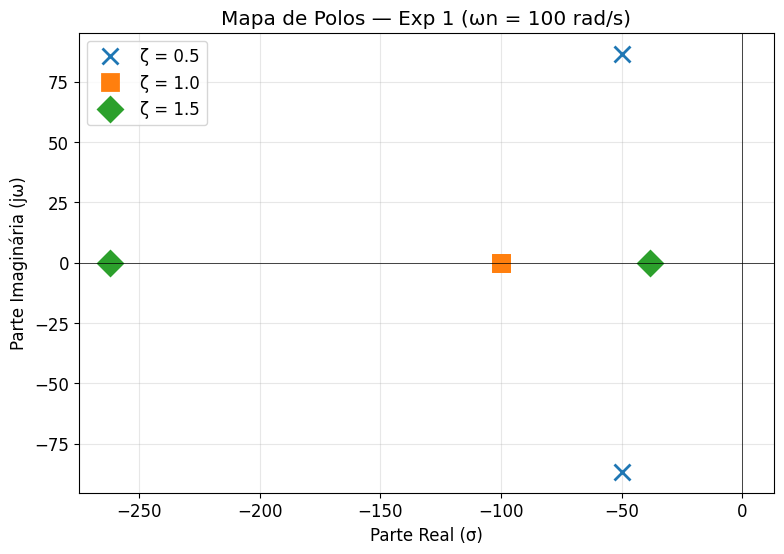

ζ = 0.5: polos = [-50.+86.60254038j -50.-86.60254038j]
ζ = 1.0: polos = [-100.+1.21020916e-06j -100.-1.21020916e-06j]
ζ = 1.5: polos = [-261.80339887+0.j  -38.19660113+0.j]


In [4]:
# ==================== Mapa de Polos — Exp 1 (ωn = 100, ζ = 0.5) ====================

wn_q3 = 100  # Para visualização conforme enunciado da Q3
zetas_plot = [0.5, 1.0, 1.5]
markers = ['x', 's', 'D']
colors_pz = ['tab:blue', 'tab:orange', 'tab:green']

fig, ax = plt.subplots(figsize=(8, 8))

for i, zeta in enumerate(zetas_plot):
    P_q3 = ctrl.tf([wn_q3**2], [1, 2*zeta*wn_q3, wn_q3**2])
    polos = P_q3.poles()
    ax.plot(polos.real, polos.imag, markers[i], markersize=12, color=colors_pz[i],
            label=f'ζ = {zeta}', markeredgewidth=2)

ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.set_xlabel('Parte Real (σ)')
ax.set_ylabel('Parte Imaginária (jω)')
ax.set_title('Mapa de Polos — Exp 1 (ωn = 100 rad/s)')
ax.legend()
ax.grid(True)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('figuras/exp1_mapa_polos.png', dpi=150, bbox_inches='tight')
plt.show()

# Imprime polos para cada caso
for zeta in zetas_plot:
    P_q3 = ctrl.tf([wn_q3**2], [1, 2*zeta*wn_q3, wn_q3**2])
    print(f"ζ = {zeta}: polos = {P_q3.poles()}")

**Questão 4: Impacto da frequência natural ($\omega_n$)**

(a) Com $\omega_n$ muito alto, a resposta fica extremamente rápida. A constante de tempo é da ordem de $\tau \approx 1/(\zeta\omega_n)$, então com $\omega_n = 100.000$ rad/s a dinâmica inteira acontece em microsegundos.

(b) Por isso o vetor de tempo vai só de 0 a 0,0002 s (200 µs). Se usássemos uma escala de segundos, a resposta apareceria como um salto instantâneo e não veríamos nada das oscilações.

**Questão 5: Caso extremo ($\zeta = 0$)**

(a) O coeficiente do termo $s$ na FT é $2\zeta\omega_n$. Com $\zeta = 0$:

$$2 \cdot 0 \cdot \omega_n = 0$$

Sobra $s^2 + \omega_n^2$ no denominador, com polos puramente imaginários em $s = \pm j\omega_n$.

(b) A resposta para $\zeta = 0$ é uma oscilação permanente (sistema marginalmente estável):

$$y(t) = 1 - \cos(\omega_n t)$$

A saída fica oscilando entre 0 e 2 para sempre, sem convergir. O sistema não dissipa energia porque os polos estão exatamente em cima do eixo imaginário.

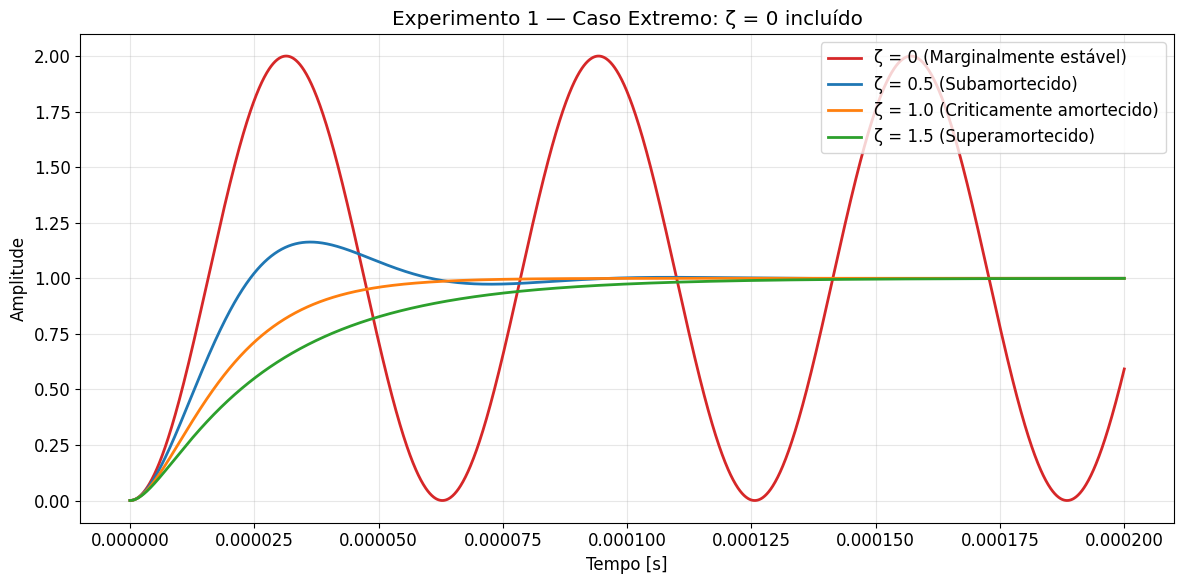

In [5]:
# ==================== Caso Extremo: ζ = 0 ====================

wn = 100000
zetas_ext = [0, 0.5, 1.0, 1.5]
labels_ext = ['ζ = 0 (Marginalmente estável)', 'ζ = 0.5 (Subamortecido)',
              'ζ = 1.0 (Criticamente amortecido)', 'ζ = 1.5 (Superamortecido)']
colors_ext = ['tab:red', 'tab:blue', 'tab:orange', 'tab:green']

t = np.arange(0, 0.0002, 0.0000001)

fig, ax = plt.subplots(figsize=(12, 6))

for i, zeta in enumerate(zetas_ext):
    P = ctrl.tf([wn**2], [1, 2*zeta*wn, wn**2])
    t_out, y_out = ctrl.step_response(P, T=t)
    ax.plot(t_out, y_out, color=colors_ext[i], label=labels_ext[i])

ax.set_xlabel('Tempo [s]')
ax.set_ylabel('Amplitude')
ax.set_title('Experimento 1 — Caso Extremo: ζ = 0 incluído')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('figuras/exp1_caso_extremo.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Experimento 2 — Efeito da adição de polos em malha fechada

### Contexto

A posição dos polos no plano-s determina a forma da resposta temporal. Aqui adicionamos polos extras à FTMF para ver como isso muda o comportamento.

### Modelo de referência

A FTMF original é:

$$T(s) = \frac{100}{s^2 + 4s + 100}$$

com $\omega_n = 10$ e $\zeta = 0{,}2$.

Ao adicionar um polo em $s = -a$, a nova FT fica:

$$T_a(s) = \frac{100 \cdot a}{(s^2 + 4s + 100)(s + a)}$$

O fator $a$ no numerador normaliza o ganho DC para manter $T(0) = 1$.

### Casos simulados

| Caso | Descrição |
|------|-----------|
| 1 | Sistema original |
| 2 | Polo em $s = -15$ |
| 3 | Polo em $s = -4$ |

--- Original: T(s) ---


        100
  ---------------
  s^2 + 4 s + 100

Polos: [-2.+9.79795897j -2.-9.79795897j]
Ganho DC: 1.0000

--- Polo em s = −15 ---


             1500
  ---------------------------
  s^3 + 19 s^2 + 160 s + 1500

Polos: [-15.+0.j          -2.+9.79795897j  -2.-9.79795897j]
Ganho DC: 1.0000

--- Polo em s = −4 ---


             400
  -------------------------
  s^3 + 8 s^2 + 116 s + 400

Polos: [-2.+9.79795897j -2.-9.79795897j -4.+0.j        ]
Ganho DC: 1.0000



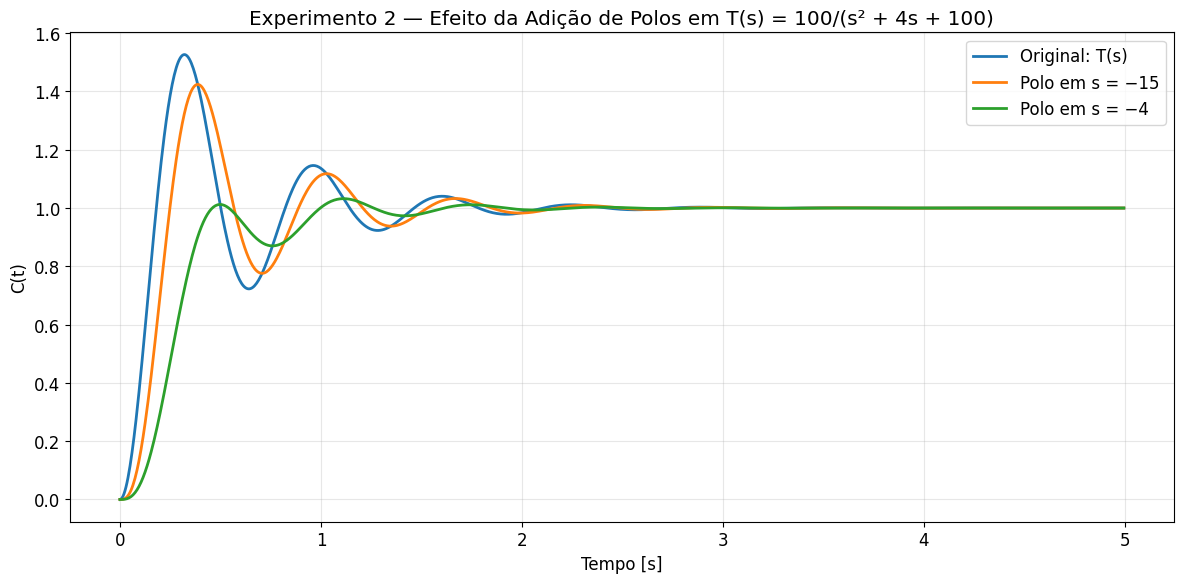

In [6]:
# ==================== Experimento 2: Adição de Polos ====================

# Sistema original: T(s) = 100 / (s^2 + 4s + 100)
T_original = ctrl.tf([100], [1, 4, 100])

# Polo em s = -15: T15(s) = 100*15 / ((s^2+4s+100)(s+15))
T_polo15 = ctrl.tf([100 * 15], np.polymul([1, 4, 100], [1, 15]))

# Polo em s = -4: T4(s) = 100*4 / ((s^2+4s+100)(s+4))
T_polo4 = ctrl.tf([100 * 4], np.polymul([1, 4, 100], [1, 4]))

sistemas = [T_original, T_polo15, T_polo4]
nomes = ['Original: T(s)', 'Polo em s = −15', 'Polo em s = −4']
colors_e2 = ['tab:blue', 'tab:orange', 'tab:green']

t = np.arange(0, 5, 0.005)

fig, ax = plt.subplots(figsize=(12, 6))

for i, (sys, nome) in enumerate(zip(sistemas, nomes)):
    t_out, y_out = ctrl.step_response(sys, T=t)
    ax.plot(t_out, y_out, color=colors_e2[i], label=nome)

    print(f"--- {nome} ---")
    print_tf("", sys)
    print(f"Polos: {sys.poles()}")
    print(f"Ganho DC: {ctrl.dcgain(sys):.4f}")
    print()

ax.set_xlabel('Tempo [s]')
ax.set_ylabel('C(t)')
ax.set_title('Experimento 2 — Efeito da Adição de Polos em T(s) = 100/(s² + 4s + 100)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('figuras/exp2_resposta_degrau.png', dpi=150, bbox_inches='tight')
plt.show()

### Respostas — Experimento 2

**Questão 1: Comparar o tempo de acomodação**

O sistema com polo em $s = -4$ é o mais lento dos três. O polo em $-4$ fica perto dos polos dominantes ($s = -2 \pm j\,9{,}8$), então interfere na dinâmica principal e aumenta o tempo de acomodação.

O polo em $s = -15$ quase não muda nada, porque está longe dos polos dominantes. A curva fica praticamente igual à do sistema original.

O original, sem polo extra, é o que acomoda mais rápido.

**Questão 2: Ganho DC $T(0)$ permanece igual a 1?**

Sim, $T(0) = 1$ em todos os casos. A conta é simples:

Para o original: $T(0) = 100 / 100 = 1$.

Para o sistema com polo em $s = -a$:

$$T_a(0) = \frac{100 \cdot a}{100 \cdot a} = 1$$

O $a$ no numerador cancela o $a$ que aparece no denominador quando $s = 0$. Foi por isso que o código multiplica o numerador por $a$.

**Questão 3: Impacto do polo em $s = -15$**

O polo em $-15$ está longe dos polos dominantes ($-2 \pm j\,9{,}8$). Como quem manda na resposta são os polos mais próximos do eixo imaginário, o polo em $-15$ quase não aparece.

O sistema continua estável. Na resposta, só aparece uma componente $e^{-15t}$ que decai quase instantaneamente e não faz diferença prática.

**Questão 4: Efeito do polo em $s = -4$**

Esse polo já está perto dos polos dominantes ($-2 \pm j\,9{,}8$), então influencia bastante.

A componente $e^{-4t}$ decai mais devagar que as oscilações do par dominante, o que puxa o tempo de acomodação para cima. O polo extra também freia a subida inicial, tirando um pouco do overshoot. No gráfico, a resposta fica visivelmente mais lenta que a do sistema original.

**Questão 5: Polo no semiplano direito**

Se o polo estivesse em $s = +4$ (semiplano direito), o sistema seria instável. A componente correspondente seria $e^{+4t}$, que cresce sem parar.

A resposta divergiria para infinito. Não importa se os outros polos são estáveis: basta um polo com parte real positiva para o sistema todo ficar instável.

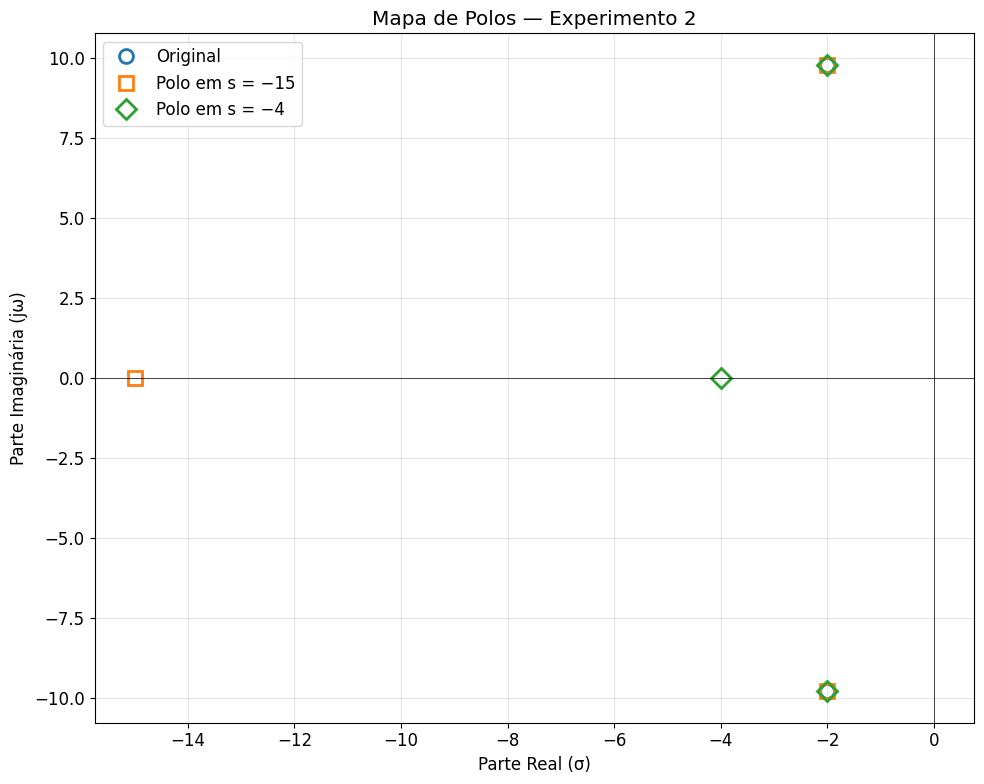

Original: polos = [-2.+9.79795897j -2.-9.79795897j]
Polo em s = −15: polos = [-15.+0.j          -2.+9.79795897j  -2.-9.79795897j]
Polo em s = −4: polos = [-2.+9.79795897j -2.-9.79795897j -4.+0.j        ]


In [7]:
# ==================== Mapa de Polos — Exp 2 ====================

fig, ax = plt.subplots(figsize=(10, 8))

nomes_pz = ['Original', 'Polo em s = −15', 'Polo em s = −4']
markers_pz = ['o', 's', 'D']
colors_pz2 = ['tab:blue', 'tab:orange', 'tab:green']

for i, (sys, nome) in enumerate(zip(sistemas, nomes_pz)):
    polos = sys.poles()
    ax.plot(polos.real, polos.imag, markers_pz[i], markersize=10, color=colors_pz2[i],
            label=nome, markeredgewidth=2, markerfacecolor='none')

ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.set_xlabel('Parte Real (σ)')
ax.set_ylabel('Parte Imaginária (jω)')
ax.set_title('Mapa de Polos — Experimento 2')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('figuras/exp2_mapa_polos.png', dpi=150, bbox_inches='tight')
plt.show()

# Imprime polos
for i, (sys, nome) in enumerate(zip(sistemas, nomes_pz)):
    print(f"{nome}: polos = {sys.poles()}")

**Questão 6: Diagramas de polos e par dominante**

No mapa de polos acima:

- Sistema original: polos em $s = -2 \pm j\,9{,}8$ (par dominante).
- Com polo em $s = -15$: mesmos polos dominantes, mais o polo real em $-15$. O par dominante não muda.
- Com polo em $s = -4$: mesmos polos dominantes, mais o polo real em $-4$. Esse polo está mais perto do par dominante e influencia a resposta, mas o par em $-2 \pm j\,9{,}8$ continua sendo o dominante (tem a parte real mais próxima do eixo imaginário).

**Questão 7: Polo em $s = -0{,}5$**

Se colocássemos o polo em $s = -0{,}5$, ele passaria a ser o polo dominante, porque está muito mais perto do eixo imaginário do que o par original ($-2 \pm j\,9{,}8$).

A resposta ficaria muito lenta, dominada por $e^{-0{,}5t}$ (constante de tempo $\tau = 2$ s). As oscilações do par complexo decairiam rápido, mas a convergência final ficaria por conta do polo em $-0{,}5$. O tempo de acomodação aumentaria bastante.

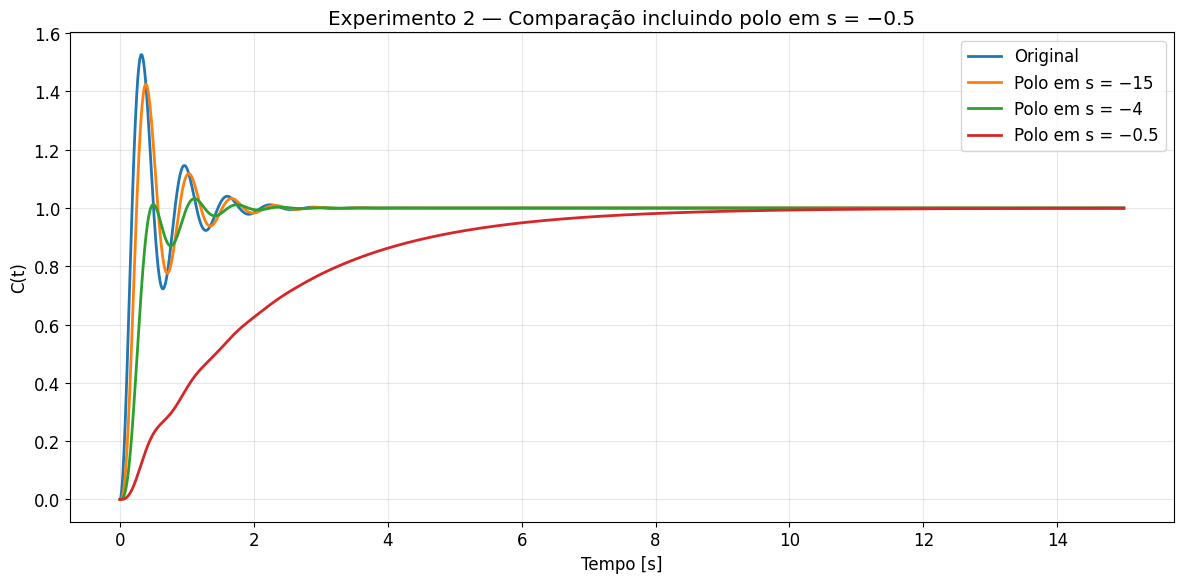

Polo em s = -0.5: polos = [-2. +9.79795897j -2. -9.79795897j -0.5+0.j        ]
Ganho DC: 1.0000


In [8]:
# ==================== Exp 2: Simulação extra — polo em s = -0.5 ====================

T_polo05 = ctrl.tf([100 * 0.5], np.polymul([1, 4, 100], [1, 0.5]))

t = np.arange(0, 15, 0.005)

fig, ax = plt.subplots(figsize=(12, 6))

sistemas_ext = [T_original, T_polo15, T_polo4, T_polo05]
nomes_ext = ['Original', 'Polo em s = −15', 'Polo em s = −4', 'Polo em s = −0.5']
colors_ext2 = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

for i, (sys, nome) in enumerate(zip(sistemas_ext, nomes_ext)):
    t_out, y_out = ctrl.step_response(sys, T=t)
    ax.plot(t_out, y_out, color=colors_ext2[i], label=nome)

ax.set_xlabel('Tempo [s]')
ax.set_ylabel('C(t)')
ax.set_title('Experimento 2 — Comparação incluindo polo em s = −0.5')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('figuras/exp2_polo_05.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Polo em s = -0.5: polos = {T_polo05.poles()}")
print(f"Ganho DC: {ctrl.dcgain(T_polo05):.4f}")

---

## Experimento 3 — Efeito de adicionar um zero $(1 + T_z s)$

### Modelo do sistema

A FTMA é:

$$G(s) = \frac{\omega_n^2}{s(s + 2\zeta\omega_n)}$$

Com a adição de um zero $(1 + T_z s)$, a FTMF fica:

$$T(s) = \frac{\omega_n^2(1 + T_z s)}{s^2 + (2\zeta\omega_n + \omega_n^2 T_z)s + \omega_n^2}$$

### Parâmetros

| Parâmetro | Valor |
|-----------|-------|
| $\zeta$ | 0,1 |
| $\omega_n$ | 1 rad/s |
| $T_z$ | 0; 0,5; 2; 5 |

Os zeros ficam em $s = -1/T_z$: sem zero ($T_z = 0$), $s = -2$ ($T_z = 0{,}5$), $s = -0{,}5$ ($T_z = 2$), $s = -0{,}2$ ($T_z = 5$).

--- Tz = 0 ---
T(s):

         1
  ---------------
  s^2 + 0.2 s + 1

Polos: [-0.1+0.99498744j -0.1-0.99498744j]
Zeros: nenhum (zero no infinito)
Ganho DC: 1.0000

--- Tz = 0.5 ---
T(s):

     0.5 s + 1
  ---------------
  s^2 + 0.7 s + 1

Polos: [-0.35+0.9367497j -0.35-0.9367497j]
Zeros: [-2.+0.j] (s = -2.00)
Ganho DC: 1.0000

--- Tz = 2 ---
T(s):

      2 s + 1
  ---------------
  s^2 + 2.2 s + 1

Polos: [-1.55825757+0.j -0.64174243+0.j]
Zeros: [-0.5+0.j] (s = -0.50)
Ganho DC: 1.0000

--- Tz = 5 ---
T(s):

      5 s + 1
  ---------------
  s^2 + 5.2 s + 1

Polos: [-5. +0.j -0.2+0.j]
Zeros: [-0.2+0.j] (s = -0.20)
Ganho DC: 1.0000



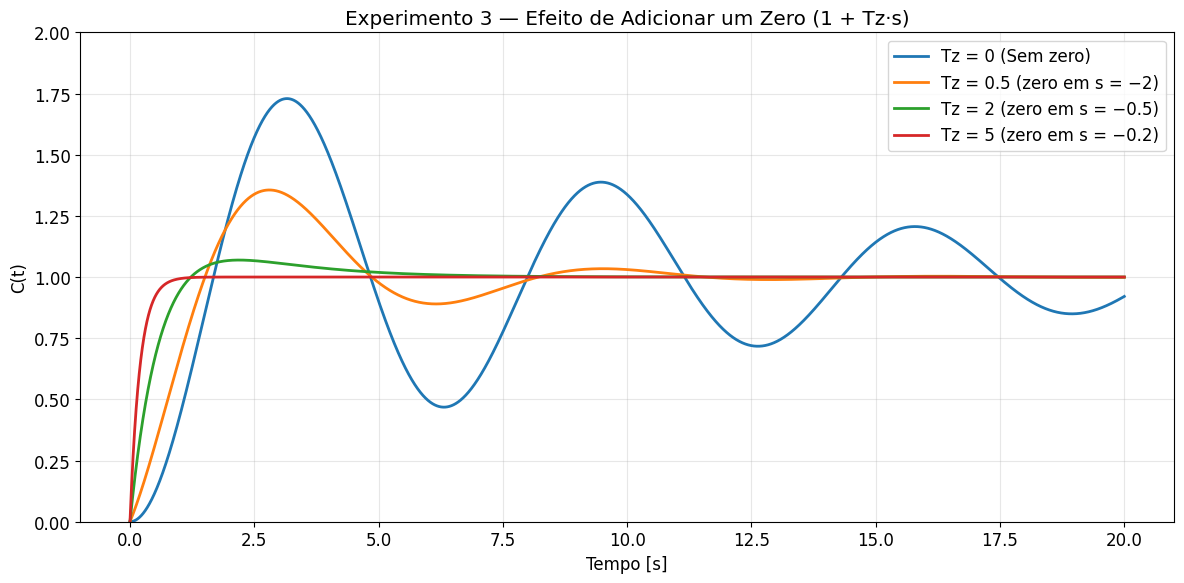

In [9]:
# ==================== Experimento 3: Efeito de Zeros ====================

zeta = 0.1
wn = 1
Tz_values = [0, 0.5, 2, 5]
labels_tz = ['Tz = 0 (Sem zero)', 'Tz = 0.5 (zero em s = −2)',
             'Tz = 2 (zero em s = −0.5)', 'Tz = 5 (zero em s = −0.2)']
colors_e3 = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

t = np.arange(0, 20, 0.001)

fig, ax = plt.subplots(figsize=(12, 6))

for i, Tz in enumerate(Tz_values):
    # T(s) = wn^2*(1 + Tz*s) / (s^2 + (2*zeta*wn + wn^2*Tz)*s + wn^2)
    num = [wn**2 * Tz, wn**2]            # wn^2*Tz*s + wn^2
    den = [1, 2*zeta*wn + wn**2*Tz, wn**2]
    T_sys = ctrl.tf(num, den)

    t_out, y_out = ctrl.step_response(T_sys, T=t)
    ax.plot(t_out, y_out, color=colors_e3[i], label=labels_tz[i])

    print(f"--- Tz = {Tz} ---")
    print_tf("T(s):", T_sys)
    print(f"Polos: {T_sys.poles()}")
    if Tz > 0:
        print(f"Zeros: {T_sys.zeros()} (s = {-1/Tz:.2f})")
    else:
        print(f"Zeros: nenhum (zero no infinito)")
    print(f"Ganho DC: {ctrl.dcgain(T_sys):.4f}")
    print()

ax.set_xlabel('Tempo [s]')
ax.set_ylabel('C(t)')
ax.set_title('Experimento 3 — Efeito de Adicionar um Zero (1 + Tz·s)')
ax.legend()
ax.grid(True)
ax.set_ylim([0, 2])
plt.tight_layout()
plt.savefig('figuras/exp3_resposta_degrau.png', dpi=150, bbox_inches='tight')
plt.show()

### Respostas — Experimento 3

**Questão 1: Efeito na resposta transitória**

Resposta: (c) -- aumenta a oscilação, aumenta o overshoot e diminui o tempo de subida.

O zero no semiplano esquerdo "puxa" a resposta para cima, acelerando a subida. O resultado é mais overshoot e resposta mais rápida. Quanto mais perto o zero está da origem, mais forte esse efeito.

**Questão 2: Posições dos zeros**

(a) $T_z = 5$ dá o maior overshoot. O zero correspondente está em $s = -0{,}2$, muito perto da origem e dos polos dominantes ($s \approx -0{,}1 \pm j\,0{,}995$). Quanto mais perto o zero está dos polos, mais ele influencia a resposta e mais overshoot aparece.

(b) $T_z = 0$ é o sistema sem zero nenhum. A FTMF vira a de segunda ordem padrão:

$$T(s) = \frac{\omega_n^2}{s^2 + 2\zeta\omega_n s + \omega_n^2}$$

Serve como referência para comparar com os outros casos.

**Questão 3: Compensação parcial do denominador**

Quando $T_z > 0$, acontecem duas coisas ao mesmo tempo.

No numerador aparece o zero $(1 + T_z s)$, que adiciona uma componente derivativa à saída. Isso acelera a resposta e puxa o overshoot para cima.

No denominador, o coeficiente de $s$ muda de $2\zeta\omega_n$ para $(2\zeta\omega_n + \omega_n^2 T_z)$, ou seja, o amortecimento efetivo sobe. Isso tende a reduzir o overshoot.

Só que a compensação é parcial: o efeito do zero no numerador ganha do aumento do amortecimento no denominador. O zero afeta direto a forma da saída (soma a derivada do sinal), enquanto o amortecimento só muda a taxa de decaimento. No saldo final, o overshoot aumenta.

**Questão 4: Zero no semiplano direito (fase não mínima)**

(a) Com um zero no semiplano direito, tipo $G(s) = \frac{1 - T_z s}{s^2 + s + 1}$, aparece um undershoot inicial: a saída vai na direção oposta antes de corrigir e subir. Isso não acontece na nossa simulação porque todos os zeros estão no semiplano esquerdo.

(b) Zeros no semiplano direito são problemáticos porque adicionam fase negativa extra, o que reduz a margem de fase. Na prática, isso limita o ganho que conseguimos usar e dificulta o projeto do controlador.

**Questão 5: Legenda $s = -1/0$**

O rótulo $s = -1/0$ para $T_z = 0$ indica um zero em $s = -\infty$.

Quando $T_z \to 0$, a posição do zero $s = -1/T_z$ vai para $-\infty$. Um zero no infinito não tem efeito nenhum na resposta, é como se ele não existisse.

Na prática, $T_z = 0$ é o sistema de segunda ordem sem zero nenhum na FT.

---

## Experimento 4 — Efeito do ganho de malha ($K$)

### Objetivo

Ver como o ganho $K$ afeta a estabilidade e o desempenho de um sistema de segunda ordem com realimentação unitária.

### Modelo do sistema

A FTMA é:

$$G(s) = \frac{\omega_n^2}{s(s + 2\zeta\omega_n)}$$

Com ganho $K$ na malha direta, a FTMF fica:

$$T(s) = \frac{K\omega_n^2}{s^2 + 2\zeta\omega_n s + K\omega_n^2}$$

### Parâmetros

| Parâmetro | Valor |
|-----------|-------|
| $\omega_n$ | 1 rad/s |
| $\zeta$ | 1 (criticamente amortecido) |
| $K$ | 1; 2; 5; 10 |

Com $K = 1$ o sistema é criticamente amortecido. Conforme $K$ aumenta, a frequência natural efetiva sobe e o amortecimento cai.

--- K = 1 ---
T(s):

        1
  -------------
  s^2 + 2 s + 1

Polos: [-1.+0.j -1.+0.j]
ωn_novo = 1.0000, ζ_novo = 1.0000
Ganho DC: 1.0000

--- K = 2 ---
T(s):

        2
  -------------
  s^2 + 2 s + 2

Polos: [-1.+1.j -1.-1.j]
ωn_novo = 1.4142, ζ_novo = 0.7071
Ganho DC: 1.0000

--- K = 5 ---
T(s):

        5
  -------------
  s^2 + 2 s + 5

Polos: [-1.+2.j -1.-2.j]
ωn_novo = 2.2361, ζ_novo = 0.4472
Ganho DC: 1.0000

--- K = 10 ---
T(s):

        10
  --------------
  s^2 + 2 s + 10

Polos: [-1.+3.j -1.-3.j]
ωn_novo = 3.1623, ζ_novo = 0.3162
Ganho DC: 1.0000



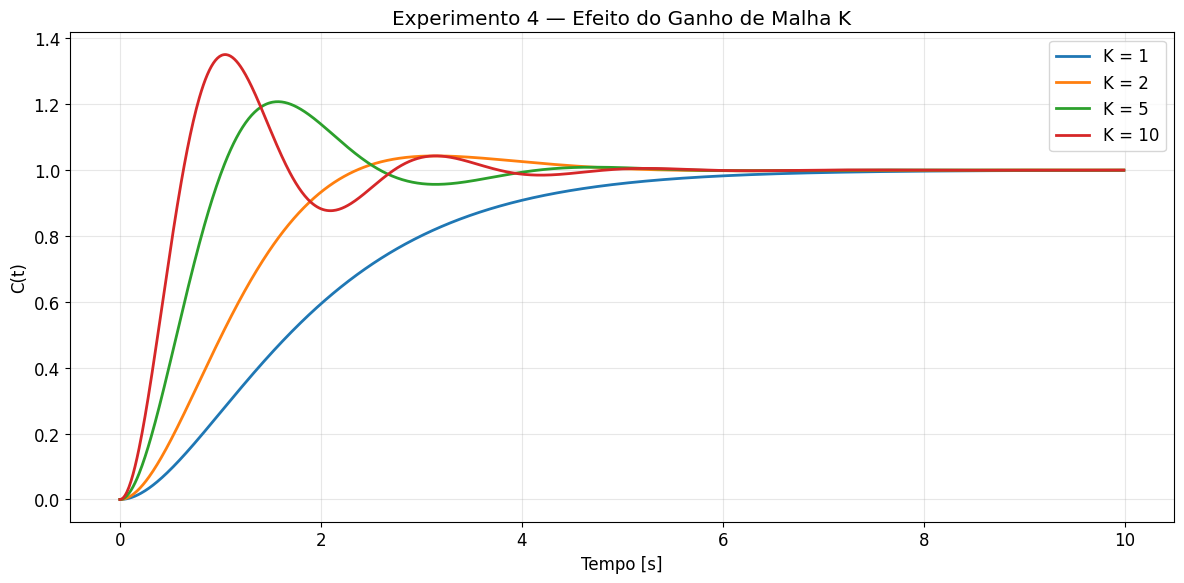

In [10]:
# ==================== Experimento 4: Efeito do Ganho K ====================

wn = 1
zeta = 1
K_values = [1, 2, 5, 10]
colors_e4 = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

t = np.arange(0, 10, 0.01)

fig, ax = plt.subplots(figsize=(12, 6))

for i, K in enumerate(K_values):
    # T(s) = K*wn^2 / (s^2 + 2*zeta*wn*s + K*wn^2)
    num = [K * wn**2]
    den = [1, 2*zeta*wn, K * wn**2]
    T_sys = ctrl.tf(num, den)

    t_out, y_out = ctrl.step_response(T_sys, T=t)
    ax.plot(t_out, y_out, color=colors_e4[i], label=f'K = {K}')

    wn_novo = np.sqrt(K) * wn
    zeta_novo = (zeta * wn) / wn_novo

    print(f"--- K = {K} ---")
    print_tf("T(s):", T_sys)
    print(f"Polos: {T_sys.poles()}")
    print(f"ωn_novo = {wn_novo:.4f}, ζ_novo = {zeta_novo:.4f}")
    print(f"Ganho DC: {ctrl.dcgain(T_sys):.4f}")
    print()

ax.set_xlabel('Tempo [s]')
ax.set_ylabel('C(t)')
ax.set_title('Experimento 4 — Efeito do Ganho de Malha K')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('figuras/exp4_resposta_degrau.png', dpi=150, bbox_inches='tight')
plt.show()

### Respostas — Experimento 4

**Questão 1: Efeito de aumentar $K$ de 1 a 10**

Conforme $K$ cresce, o sistema sai de criticamente amortecido ($K = 1$, $\zeta_{\text{novo}} = 1$) e vai ficando cada vez mais subamortecido ($\zeta_{\text{novo}} < 1$).

O que se vê no gráfico: mais overshoot porque o amortecimento cai, tempo de subida menor porque a frequência natural $\omega_{n,\text{novo}} = \sqrt{K} \cdot \omega_n$ aumenta, e oscilações mais pronunciadas. Com $K = 10$ o sistema balança várias vezes antes de assentar.

**Questão 2: Cálculo de $\zeta_{\text{novo}}$ para $K = 4$**

(a) A equação característica é $s^2 + 2\zeta\omega_n s + K\omega_n^2 = 0$. Com $\omega_n = 1$ e $\zeta = 1$:

$$s^2 + 2s + 4 = 0$$

Frequência natural efetiva: $\omega_{n,\text{novo}} = \sqrt{4} = 2$ rad/s.

Amortecimento efetivo:

$$\zeta_{\text{novo}} = \frac{2\zeta\omega_n}{2\omega_{n,\text{novo}}} = \frac{2}{4} = 0{,}5$$

(b) Como $\zeta_{\text{novo}} = 0{,}5 < 1$, a resposta é subamortecida, com oscilações e overshoot.

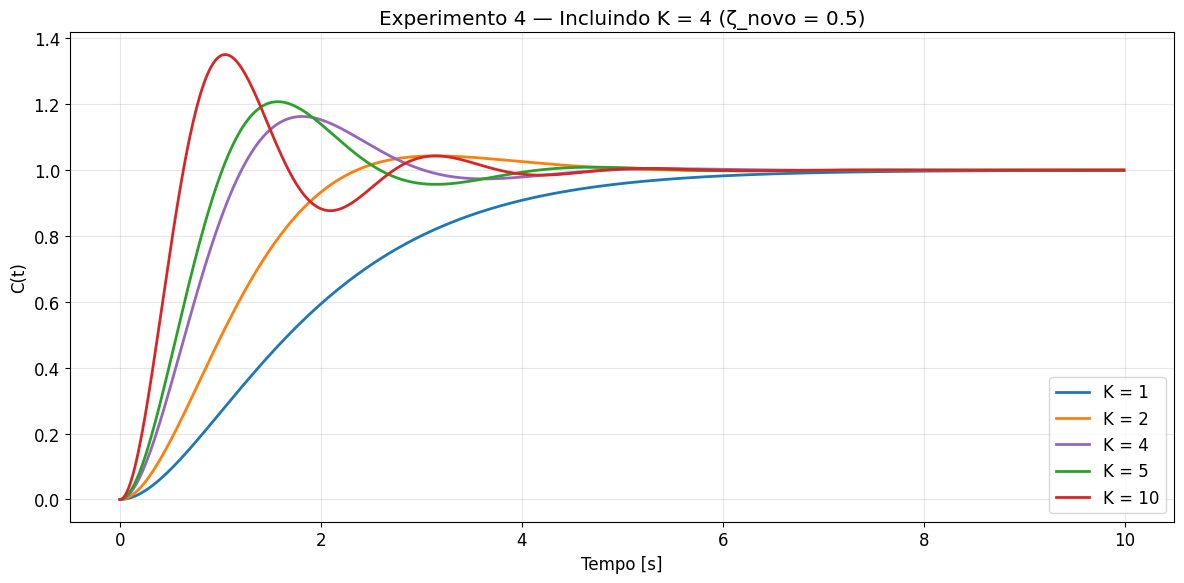

In [11]:
# ==================== Exp 4: Simulação extra — K = 4 ====================

K_ext = [1, 2, 4, 5, 10]
colors_ext4 = ['tab:blue', 'tab:orange', 'tab:purple', 'tab:green', 'tab:red']

t = np.arange(0, 10, 0.01)

fig, ax = plt.subplots(figsize=(12, 6))

for i, K in enumerate(K_ext):
    num = [K * wn**2]
    den = [1, 2*zeta*wn, K * wn**2]
    T_sys = ctrl.tf(num, den)
    t_out, y_out = ctrl.step_response(T_sys, T=t)
    ax.plot(t_out, y_out, color=colors_ext4[i], label=f'K = {K}')

ax.set_xlabel('Tempo [s]')
ax.set_ylabel('C(t)')
ax.set_title('Experimento 4 — Incluindo K = 4 (ζ_novo = 0.5)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('figuras/exp4_K4.png', dpi=150, bbox_inches='tight')
plt.show()

**Questão 3: Comparar $K = 2$ com $K = 10$**

(a) $K = 10$ tem o Rise Time mais rápido. A frequência natural efetiva é $\omega_{n,\text{novo}} = \sqrt{K}$: para $K = 10$ temos $3{,}16$ rad/s contra $1{,}41$ rad/s para $K = 2$. Frequência maior, resposta mais rápida.

(b) $K = 10$ também tem o overshoot maior. O amortecimento efetivo é $\zeta_{\text{novo}} = 1/\sqrt{K}$:

- $K = 2$: $\zeta_{\text{novo}} = 0{,}707$, overshoot de $\approx 4{,}3\%$
- $K = 10$: $\zeta_{\text{novo}} = 0{,}316$, overshoot de $\approx 35{,}2\%$

Fórmula do overshoot: $M_p = e^{-\pi\zeta/\sqrt{1-\zeta^2}} \times 100\%$. Quanto menor $\zeta$, maior o overshoot.

**Questão 4: Estabilidade**

(a) Os polos em malha fechada são:

$$s_{1,2} = -\zeta\omega_n \pm \omega_n\sqrt{\zeta^2 - K}$$

Com $\zeta = 1$ e $\omega_n = 1$, para $K > 1$:

$$s_{1,2} = -1 \pm j\sqrt{K - 1}$$

A parte real é sempre $-1$, não importa o valor de $K$. Como é negativa, o sistema é estável para qualquer $K > 0$. Os polos só se movem na vertical, nunca cruzam o eixo imaginário.

(b) Para o sistema de 3ª ordem $G'(s) = \frac{K}{s(s+1)(s+2)}$, a situação muda. Pelo critério de Routh-Hurwitz, existe $K_{\text{crit}} = 6$: acima disso o sistema de malha fechada fica instável. Sistemas de ordem $\geq 3$ podem ter polos que cruzam para o semiplano direito quando o ganho sobe.

**Questão 5: Importância do termo $K\omega_n^2$ no denominador**

O denominador da FTMF é $s^2 + 2\zeta\omega_n s + K\omega_n^2$. O termo $K\omega_n^2$ fixa a frequência natural efetiva:

$$\omega_{n,\text{novo}} = \sqrt{K} \cdot \omega_n$$

E o amortecimento efetivo fica:

$$\zeta_{\text{novo}} = \frac{\zeta}{\sqrt{K}}$$

Então quando $K$ sobe: $\omega_{n,\text{novo}}$ cresce (sistema mais rápido), mas $\zeta_{\text{novo}}$ cai (sistema mais oscilatório). Os polos saem de reais coincidentes ($K = 1$) para um par complexo com parte imaginária cada vez maior ($K > 1$).

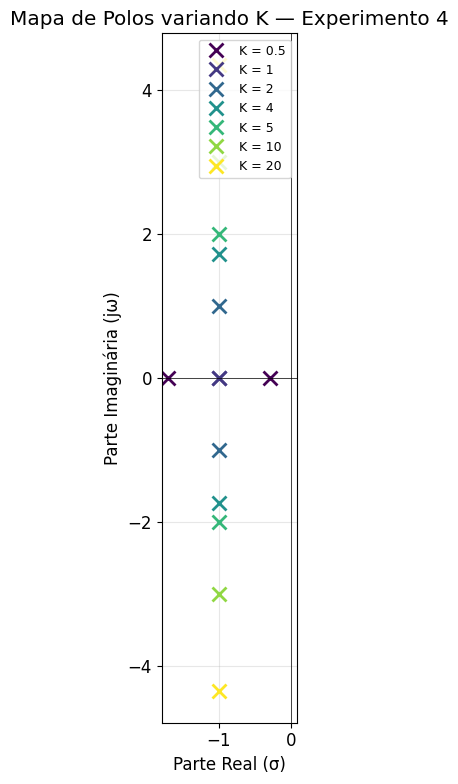

In [12]:
# ==================== Mapa de Polos variando K — Exp 4 ====================

fig, ax = plt.subplots(figsize=(8, 8))

K_range = [0.5, 1, 2, 4, 5, 10, 20]
colors_map = plt.cm.viridis(np.linspace(0, 1, len(K_range)))

for i, K in enumerate(K_range):
    num = [K * wn**2]
    den = [1, 2*zeta*wn, K * wn**2]
    T_sys = ctrl.tf(num, den)
    polos = T_sys.poles()
    ax.plot(polos.real, polos.imag, 'x', markersize=10, color=colors_map[i],
            label=f'K = {K}', markeredgewidth=2)

ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.set_xlabel('Parte Real (σ)')
ax.set_ylabel('Parte Imaginária (jω)')
ax.set_title('Mapa de Polos variando K — Experimento 4')
ax.legend(fontsize=9)
ax.grid(True)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('figuras/exp4_mapa_polos.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Conclusões

Com os quatro experimentos, ficou claro que:

1. O fator de amortecimento $\zeta$ controla a forma da resposta. Com $\zeta < 1$ o sistema oscila, $\zeta = 1$ é o mais rápido sem overshoot, e $\zeta > 1$ é lento e sem oscilação.

2. Polos extras longe dos polos dominantes quase não fazem diferença. Polos perto da origem viram dominantes e deixam tudo mais lento. Polo no semiplano direito é instabilidade na certa.

3. Zeros no semiplano esquerdo aceleram a resposta mas aumentam o overshoot, e esse efeito é mais forte quanto mais perto da origem o zero estiver. Zero no semiplano direito causa undershoot e complica o controle.

4. Aumentar o ganho $K$ faz o sistema responder mais rápido ($\omega_n$ efetivo sobe), mas com mais overshoot ($\zeta$ efetivo cai). Em 2ª ordem o sistema é estável para qualquer $K > 0$, mas em ordens maiores pode haver um $K$ crítico que desestabiliza tudo.